In [21]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import kagglehub
# If using the ResNet50 preprocess_input
from tensorflow.keras.applications.resnet50 import preprocess_input

In [22]:
import os

# Base KaggleHub download path
asl_path = r"C:\Users\User\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1"

# ✅ Correct subfolder (contains A,B,C,...)
asl_train_dir = os.path.join(asl_path, "asl_alphabet_train", "asl_alphabet_train")

print("✅ Dataset path:", asl_train_dir)
print("📁 Folders inside:", os.listdir(asl_train_dir)[:10])


✅ Dataset path: C:\Users\User\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train\asl_alphabet_train
📁 Folders inside: ['A', 'B', 'C', 'D', 'del', 'E', 'F', 'G', 'H', 'I']


In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# 🧩 Strong but safe augmentation setup
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # resnet normalization
    rotation_range=25,        # random rotations ±25°
    width_shift_range=0.2,    # horizontal shift ±20%
    height_shift_range=0.2,   # vertical shift ±20%
    zoom_range=0.25,          # random zoom
    shear_range=0.15,         # shear distortion
    brightness_range=[0.7, 1.3],  # random brightness
    channel_shift_range=40.0,     # color balance variation
    horizontal_flip=True,     # flip horizontally (safe for ASL)
    fill_mode='nearest',      # fill empty pixels after transformation
    validation_split=0.2      # 20% for validation
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    asl_train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    asl_train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)


Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.


In [24]:
print("📦 Training batches:", len(train_gen))
print("📦 Validation batches:", len(val_gen))
print("🏷️ Classes detected:", train_gen.num_classes)
print("🧩 Class indices:", train_gen.class_indices)


📦 Training batches: 2175
📦 Validation batches: 544
🏷️ Classes detected: 29
🧩 Class indices: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25, 'del': 26, 'nothing': 27, 'space': 28}


In [25]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model

# 🔹 Load pretrained ResNet50 backbone (no top classifier)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# 🔹 Freeze ALL base layers
for layer in base_model.layers:
    layer.trainable = False

print(f"🔒 Total frozen layers: {len(base_model.layers)}")

# 🔹 Add new classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
outputs = Dense(train_gen.num_classes, activation='softmax')(x)


model = Model(inputs=base_model.input, outputs=outputs)
model.summary()


🔒 Total frozen layers: 175


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,647,133 (90.21 MB)

 Trainable params: 59,421 (232.11 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [26]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



In [27]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6),
    ModelCheckpoint('resnet50_asl_best_frozen.keras', monitor='val_accuracy', save_best_only=True)
]

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_gen, validation_data=val_gen, epochs=10)


Epoch 1/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 2922s 1s/step - accuracy: 0.7032 - loss: 0.9872 - val_accuracy: 0.8052 - val_loss: 0.6597
Epoch 2/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 2734s 1s/step - accuracy: 0.8142 - loss: 0.5818 - val_accuracy: 0.8109 - val_loss: 0.6226
Epoch 3/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 2330s 1s/step - accuracy: 0.8292 - loss: 0.5338 - val_accuracy: 0.8114 - val_loss: 0.6214
Epoch 4/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 2173s 999ms/step - accuracy: 0.8371 - loss: 0.5192 - val_accuracy: 0.8401 - val_loss: 0.5526
Epoch 5/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 2149s 988ms/step - accuracy: 0.8417 - loss: 0.5070 - val_accuracy: 0.8429 - val_loss: 0.5693
Epoch 6/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 2381s 1s/step - accuracy: 0.8441 - loss: 0.5040 - val_accuracy: 0.8218 - val_loss: 0.6306
Epoch 7/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 2232s 1s/step - accuracy: 0.8481 - loss: 0.4955 - val_accuracy: 0.8283 - val_loss: 0.5953
Epoch 8/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 2299s 1s/step - accuracy: 0.

# Fine Tuning

In [30]:
for layer in base_model.layers[-50:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 3008s 1s/step - accuracy: 0.9243 - loss: 0.2734 - val_accuracy: 0.9171 - val_loss: 0.3000 - learning_rate: 1.0000e-05
Epoch 2/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 3001s 1s/step - accuracy: 0.9648 - loss: 0.1133 - val_accuracy: 0.9280 - val_loss: 0.2778 - learning_rate: 1.0000e-05
Epoch 3/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 2975s 1s/step - accuracy: 0.9773 - loss: 0.0727 - val_accuracy: 0.9393 - val_loss: 0.2493 - learning_rate: 1.0000e-05
Epoch 4/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 2961s 1s/step - accuracy: 0.9834 - loss: 0.0542 - val_accuracy: 0.9390 - val_loss: 0.2292 - learning_rate: 1.0000e-05
Epoch 5/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 2976s 1s/step - accuracy: 0.9865 - loss: 0.0415 - val_accuracy: 0.9427 - val_loss: 0.2206 - learning_rate: 1.0000e-05


In [32]:
# 🧠 Evaluate on the validation generator
val_loss, val_acc = model.evaluate(val_gen, verbose=1)

print(f"\n✅ Validation Accuracy: {val_acc * 100:.2f}%")
print(f"📉 Validation Loss: {val_loss:.4f}")


544/544 ━━━━━━━━━━━━━━━━━━━━ 402s 739ms/step - accuracy: 0.9427 - loss: 0.2206    

✅ Validation Accuracy: 94.27%
📉 Validation Loss: 0.2206


In [33]:
# Save in modern .keras format (recommended)
model.save("resnet50_asl_augmented_frozen.keras")
print("✅ Model saved as 'resnet50_asl_augmented_frozen.keras'")

# Optional: legacy HDF5 format for older Keras/TensorFlow versions
model.save("resnet50_asl_augmented_frozen.h5")
print("📦 Also saved as 'resnet50_asl_augmented_frozen.h5'")


✅ Model saved as 'resnet50_asl_augmented_frozen.keras'
📦 Also saved as 'resnet50_asl_augmented_frozen.h5'


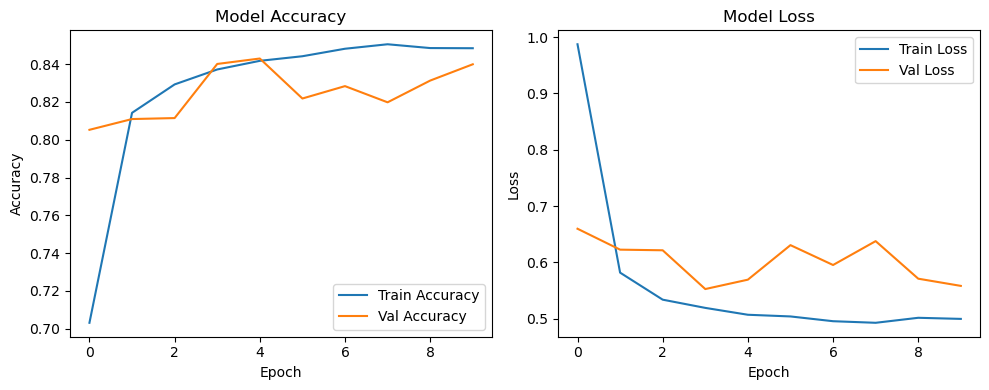

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
